In [6]:
import pyclara
import sdds
import matplotlib.pyplot as plt
import numpy as np

In [7]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

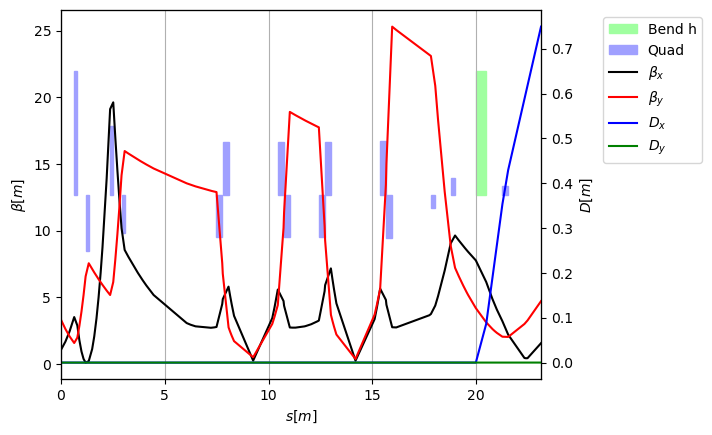

In [4]:
xsuite_twiss['xtrack_twiss'].plot()

### Compare XSuite with Elegant

Difference in spectrometer bend is due to edge effects which are *on* in both codes

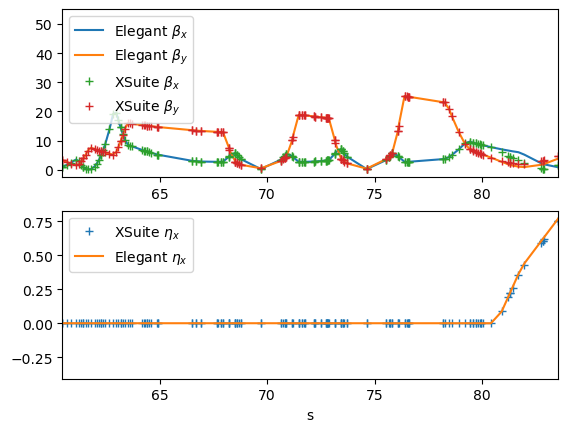

In [13]:
xtrack_twiss =xsuite_twiss['xtrack_twiss']
elegant_twi = sdds.load("../Run/FEBE.twi")

elegant_s = np.array(elegant_twi.getColumnValueList('s'))
elegant_betax = np.array(elegant_twi.getColumnValueList('betax'))
elegant_betay = np.array(elegant_twi.getColumnValueList('betay'))
elegant_etax =  np.array(elegant_twi.getColumnValueList('etax'))

s0 = xsuite_twiss['env'].lines['FEBE'].particle_ref.s

plt.subplot(2,1,1)
plt.plot(elegant_s, elegant_betax,"-", label="Elegant $\\beta_x$")
plt.plot(elegant_s, elegant_betay,"-", label="Elegant $\\beta_y$")
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['betx'],"+", label="XSuite $\\beta_x$")
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['bety'],"+", label="XSuite $\\beta_y$")
plt.xlim(s0,elegant_s.max())
plt.legend()

plt.subplot(2,1,2)
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['dx'],"+", label="XSuite $\\eta_x$")
plt.plot(elegant_s, elegant_etax,"-", label="Elegant $\\eta_x$")
plt.xlim(s0,elegant_s.max())
plt.xlabel("s");
plt.legend()

plt.savefig("XSuite_ElegantComparision.jpg")

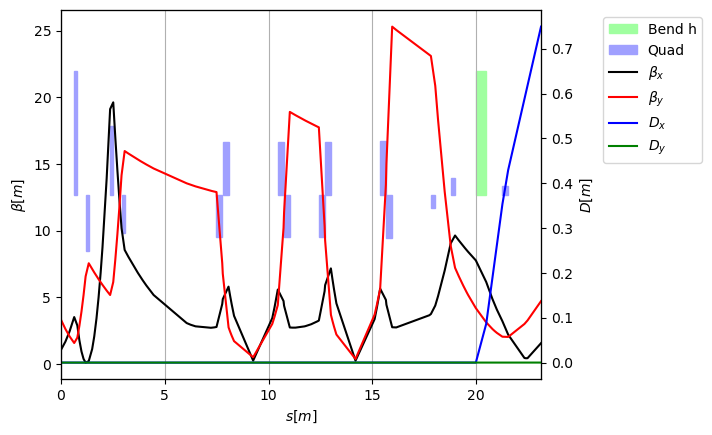

In [9]:
xtrack_twiss.plot()

### XSuite tracking

In [5]:
xsuite_track = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_ps="../Run/CLA-FEA-SIM-DIP-04-END.SDDS")